In [97]:
import seaborn as sns
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
df = sns.load_dataset("tips")


In [4]:
df.head(10)

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4
5,25.29,4.71,Male,No,Sun,Dinner,4
6,8.77,2.00,Male,No,Sun,Dinner,2
7,26.88,3.12,Male,No,Sun,Dinner,4
8,15.04,1.96,Male,No,Sun,Dinner,2
9,14.78,3.23,Male,No,Sun,Dinner,2


In [6]:
df.tail(10)

,total_bill,tip,sex,smoker,day,time,size
234,15.53,3.00,Male,Yes,Sat,Dinner,2
235,10.07,1.25,Male,No,Sat,Dinner,2
236,12.60,1.00,Male,Yes,Sat,Dinner,2
237,32.83,1.17,Male,Yes,Sat,Dinner,2
238,35.83,4.67,Female,No,Sat,Dinner,3
239,29.03,5.92,Male,No,Sat,Dinner,3
240,27.18,2.00,Female,Yes,Sat,Dinner,2
241,22.67,2.00,Male,Yes,Sat,Dinner,2
242,17.82,1.75,Male,No,Sat,Dinner,2
243,18.78,3.00,Female,No,Thur,Dinner,2


In [8]:
df.shape

(244, 7)

In [10]:
df.dtypes

total_bill     float64
tip            float64
sex           category
smoker        category
day           category
time          category
size             int64
dtype: object

In [16]:
print(df['total_bill'].mean())
print(df['tip'].mean())

19.78594262295082
2.99827868852459


In [20]:
df["test"] = np.arange(0,244)

In [22]:
df

,total_bill,tip,sex,smoker,day,time,size,test
0,16.99,1.01,Female,No,Sun,Dinner,2,0
1,10.34,1.66,Male,No,Sun,Dinner,3,1
2,21.01,3.50,Male,No,Sun,Dinner,3,2
3,23.68,3.31,Male,No,Sun,Dinner,2,3
4,24.59,3.61,Female,No,Sun,Dinner,4,4
...,...,...,...,...,...,...,...,...
239,29.03,5.92,Male,No,Sat,Dinner,3,239
240,27.18,2.00,Female,Yes,Sat,Dinner,2,240
241,22.67,2.00,Male,Yes,Sat,Dinner,2,241
242,17.82,1.75,Male,No,Sat,Dinner,2,242


In [27]:
df.drop(columns=['test'], inplace=True)

In [28]:
df

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4
...,...,...,...,...,...,...,...
239,29.03,5.92,Male,No,Sat,Dinner,3
240,27.18,2.00,Female,Yes,Sat,Dinner,2
241,22.67,2.00,Male,Yes,Sat,Dinner,2
242,17.82,1.75,Male,No,Sat,Dinner,2


In [29]:
df["tip_percentage"] = (df["tip"]/ (df['total_bill'] - df['tip'])) * 100

In [80]:
df.sample(5)

,total_bill,tip,sex,smoker,day,time,size,tip_percentage
147,11.87,1.63,Female,No,Thur,Lunch,2,15.917969
192,28.44,2.56,Male,Yes,Thur,Lunch,2,9.891808
80,19.44,3.00,Male,Yes,Thur,Lunch,2,18.248175
48,28.55,2.05,Male,No,Sun,Dinner,3,7.735849
15,21.58,3.92,Male,No,Sun,Dinner,2,22.197055


In [96]:
tip_per = df['tip_percentage'].to_numpy()
np.mean(tip_per)
np.median(tip_per)
np.std(tip_per)
np.max(tip_per)
np.min(tip_per)


np.float64(3.695514845230575)

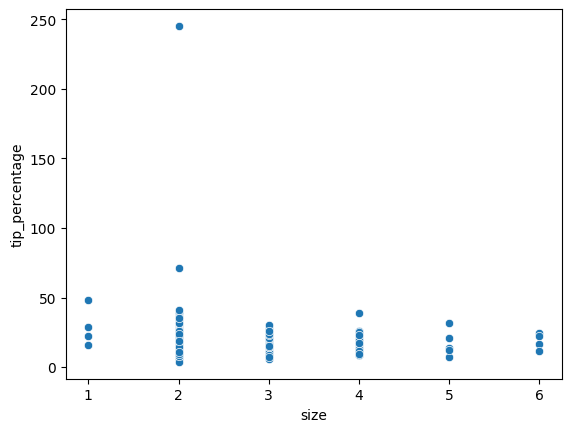

In [98]:
size = df["size"]
tip_percentage = df["tip_percentage"]
sns.scatterplot(x=size, y=tip_percentage)
plt.show()


In [100]:
mean_tip = df["tip"].mean()
mean_tip

np.float64(2.99827868852459)

In [102]:
df[df["tip"] > 1].shape

(240, 8)

In [109]:
above_average = df[df["tip"] > mean_tip]


In [110]:
above_average

,total_bill,tip,sex,smoker,day,time,size,tip_percentage
2,21.01,3.50,Male,No,Sun,Dinner,3,19.988578
3,23.68,3.31,Male,No,Sun,Dinner,2,16.249386
4,24.59,3.61,Female,No,Sun,Dinner,4,17.206864
5,25.29,4.71,Male,No,Sun,Dinner,4,22.886297
7,26.88,3.12,Male,No,Sun,Dinner,4,13.131313
...,...,...,...,...,...,...,...,...
232,11.61,3.39,Male,No,Sat,Dinner,2,41.240876
234,15.53,3.00,Male,Yes,Sat,Dinner,2,23.942538
238,35.83,4.67,Female,No,Sat,Dinner,3,14.987163
239,29.03,5.92,Male,No,Sat,Dinner,3,25.616616


In [115]:
df.groupby("day")["tip_percentage"].mean()

day
Thur    19.481779
Fri     20.859767
Sat     18.530480
Sun     22.571784
Name: tip_percentage, dtype: float64

In [118]:
df["size"].mean()

np.float64(2.569672131147541)

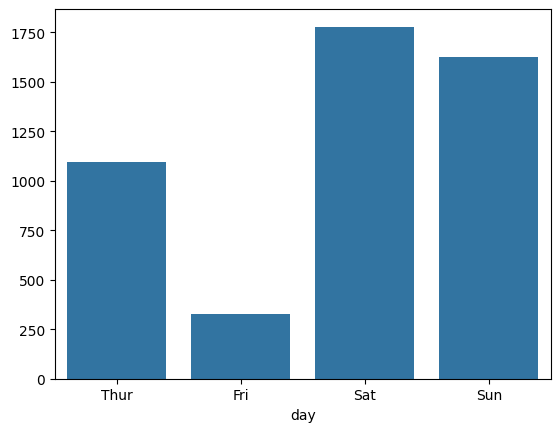

In [134]:
day_vs_rev = df.groupby("day")["total_bill"].sum()
sns.barplot(x= day_vs_rev.index, y = day_vs_rev.values)
plt.show()

In [143]:
df['is_weekend'] = df['day'].isin(['Sat', 'Sun']).astype(int)

In [144]:
df.sample(5)

,total_bill,tip,sex,smoker,day,time,size,tip_percentage,is_weekend
124,12.48,2.52,Female,No,Thur,Lunch,2,25.301205,0
46,22.23,5.00,Male,No,Sun,Dinner,2,29.019153,1
160,21.50,3.50,Male,No,Sun,Dinner,4,19.444444,1
40,16.04,2.24,Male,No,Sat,Dinner,3,16.231884,1
240,27.18,2.00,Female,Yes,Sat,Dinner,2,7.942812,1


In [150]:
df.drop(columns=["day"], inplace=True)

In [151]:
df.sample(5)

,total_bill,tip,sex,smoker,time,size,tip_percentage,is_weekend
27,12.69,2.00,Male,No,Dinner,2,18.709074,1
128,11.38,2.00,Female,No,Lunch,2,21.321962,0
243,18.78,3.00,Female,No,Dinner,2,19.011407,0
34,17.78,3.27,Male,No,Dinner,2,22.536182,1
56,38.01,3.00,Male,Yes,Dinner,4,8.568980,1
